# Open recordings and verify quality and coverage

In [1]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 
import heartpy as hp

from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d

In [2]:
%load_ext autoreload
%autoreload 1
%aimport qex
%aimport rp2
%aimport mh

In [3]:
 %reload_ext autoreload

In [4]:
def rmssd(ibi_list):
    ibi_list = pd.Series(ibi_list)
    ms = np.sqrt(ibi_list.diff().pow(2).sum()/(len(ibi_list)-1))
    return ms

def HR_avg(ibi_list):
    ibi_list = pd.Series(ibi_list)
    bpm = 60000/ibi_list.mean()
    return bpm


def get_spectrogram(datain,F,W,J,scale='log'):
    '''Makes a spectrogram of the given data.
    #
    df: dataframe with data
    F: sampling frequency
    W: Window size
    J: Separation between windows
    #
    output: if input is Series output is a signle DF with spectrogram
            if intput is DF the output is dictionary with one spectrogram per column of the input dataframe
    '''
    K = range(0,len(datain)-W,J) # starting point for the windows
    K0 = [int(x+W/2) for x in K] # placing them in the middle point timestamp
    new_index = [datain.index[x] for x in K0] # extracting those timestamps
    col_freqs = [x*F/W for x in range(int(W/2)+1) ] # values of resolved freqs
    #   print(len(new_index),len(col_freqs))
    han = np.hanning(W)
    #dic = {'window_size':W,'sampling_frequency':F}
    #
    dic = {}
    for col in datain.columns:
        fourier = np.zeros((len(new_index),len(col_freqs)))
        temp = np.zeros((1,int(W/2)+1))
        j = 0
        D = datain[col]
#         D = D.diff() # discrete derivative
        D = D.dropna() # discarding nans and concatenating
        if len(D)==0:
            continue
        #   
        K0 = range(0,len(D)-W,J) # starting point for the windows
        for T0 in K0:
            data0 = D.iloc[T0:T0+W]*han
            if scale=='log':
                temp = 10*np.log10(2*abs(np.fft.fft(data0,axis=0)))
            elif scale=='abs':
                temp = abs(np.fft.fft(data0,axis=0))
            fourier[j,:] = temp[:int(W/2)+1]
            j = 1 + j
            #
        res = pd.DataFrame(fourier,index=new_index,columns=col_freqs)
#         res1 = res / (res.columns) # multiplicative adjustment for discrete derivative
        dic[col] = res#1      
        #print('Ready with ',col)
    output = dic
    #
    return output


## load example data

In [5]:
sess_tag = 'Sess0614'

In [6]:
Timing_file = pd.read_csv('../Timing/Onset times, session 1.3.csv',skiprows=5)
Timing_file

,Times,HR,RMSSD,Resp.,Movem.,Unnamed: 5,Times.1,HR.1,RMSSD.1,Resp..1,Movem..1
0,07:32:48,NaN,NaN,NaN,NaN,NaN,07:32:48,NaN,NaN,NaN,NaN
1,07:37:00,NaN,NaN,NaN,NaN,NaN,07:37:00,NaN,NaN,NaN,NaN
2,07:40:23,NaN,NaN,NaN,NaN,NaN,07:40:23,NaN,NaN,NaN,NaN
3,07:44:33,NaN,NaN,NaN,NaN,NaN,07:44:33,NaN,NaN,NaN,NaN
4,07:48:46,NaN,NaN,NaN,NaN,NaN,07:48:46,NaN,NaN,NaN,NaN
5,07:50:03,NaN,NaN,NaN,NaN,NaN,07:50:03,NaN,NaN,NaN,NaN
6,07:52:44,NaN,NaN,NaN,NaN,NaN,07:52:44,NaN,NaN,NaN,NaN
7,07:56:53,NaN,NaN,NaN,NaN,NaN,07:56:53,NaN,NaN,NaN,NaN
8,07:59:03,NaN,NaN,NaN,NaN,NaN,07:59:03,NaN,NaN,NaN,NaN
9,08:02:46,NaN,NaN,NaN,NaN,NaN,08:02:46,NaN,NaN,NaN,NaN


In [7]:
Excerpt_times = pd.to_datetime('June 14th, 2023, ' + Timing_file.loc[:17,'Times'])
Excerpt_times

0    2023-06-14 07:32:48
1    2023-06-14 07:37:00
2    2023-06-14 07:40:23
3    2023-06-14 07:44:33
4    2023-06-14 07:48:46
5    2023-06-14 07:50:03
6    2023-06-14 07:52:44
7    2023-06-14 07:56:53
8    2023-06-14 07:59:03
9    2023-06-14 08:02:46
10   2023-06-14 08:06:18
11   2023-06-14 08:09:42
12   2023-06-14 08:11:56
13   2023-06-14 08:16:03
14   2023-06-14 08:18:43
15   2023-06-14 08:23:24
16   2023-06-14 08:26:07
17   2023-06-14 08:29:08
Name: Times, dtype: datetime64[ns]

In [8]:
data_loc = '../Equivitals_Sessions1/'
eqfiles = qex.qiosk_rec_check(data_loc,'','/')
eqfiles = qex.remove_tz_from_dataframe(eqfiles)

In [9]:
eqfiles

,Signal,DevName,ID,Date,Session,FileName,FileType,FileSize,RecStart,RecEnd,...,SubjectNames,SENSOR ID,SUBJECT ID,SUBJECT AGE,HR(BPM),HRC(%),BELT OFF,LEAD OFF,MOTION,BODY POSITION
0,DATA,BLUETOOTH01,5022281,230524,0,DATA-BLUETOOTH01-5022281-23052400.CSV,csv,28098,2023-05-24 08:16:08,2023-05-24 09:34:23,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,NaN,62,99.0,0.0,0.0,Stationary,Upright
1,DATA,BLUETOOTH03,5022292,230524,0,DATA-BLUETOOTH03-5022292-23052400.CSV,csv,28550,2023-05-24 08:16:56,2023-05-24 09:36:26,...,[BLUETOOTH03],5022292.0,BLUETOOTH03,NaN,80,98.0,0.0,0.0,Stationary,Upright
2,DATA,BLUETOOTH01,5022281,230607,101,DATA-BLUETOOTH01-5022281-23060700_0.CSV,csv,31895,2023-06-07 08:12:51,2023-06-07 09:41:36,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,NaN,61,99.0,0.0,0.0,Stationary,Upright
3,DATA,BLUETOOTH02,5022285,230607,101,DATA-BLUETOOTH02-5022285-23060700_0.CSV,csv,31987,2023-06-07 08:13:29,2023-06-07 09:42:29,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,NaN,80,97.0,0.0,0.0,Stationary,Upright
4,DATA,BLUETOOTH02,5022285,230614,0,DATA-BLUETOOTH02-5022285-23061400.CSV,csv,25872,2023-06-14 07:22:35,2023-06-14 08:34:35,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,NaN,77,98.0,0.0,0.0,Stationary,Upright
5,DATA,BLUETOOTH01,5022281,230614,101,DATA-BLUETOOTH01-5022281-23061400_0.CSV,csv,25181,2023-06-14 07:23:47,2023-06-14 08:33:32,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,NaN,61,100.0,0.0,0.0,Stationary,Upright
6,DATA,BLUETOOTH02,5022285,230621,101,DATA-BLUETOOTH02-5022285-23062100_0.CSV,csv,25737,2023-06-21 08:21:54,2023-06-21 09:33:24,...,[BLUETOOTH02],5022285.0,BLUETOOTH02,NaN,86,98.0,0.0,0.0,Stationary,Upright
7,DATA,BLUETOOTH01,5022281,230621,0,DATA-BLUETOOTH01-5022281-23062100.CSV,csv,25336,2023-06-21 08:22:30,2023-06-21 09:32:45,...,[BLUETOOTH01],5022281.0,BLUETOOTH01,NaN,60,100.0,0.0,0.0,Stationary,Upright


It seems we don't have the correct physiologial measurement files, dating 23 oct and 24 april, not May (24) and June 2023 (7, 14, 21, 28).


Below I've constructed the evaluation process, which should be easily ammended to evaluate the correct files.

### cardiac cleaning

In [10]:
Evs = []

In [11]:
recindex = 4 

In [13]:
recindex = 5

In [14]:
# sess_tag = 'Sess0545'
dev_tag = eqfiles.loc[recindex,'DevName']

V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>200').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

A = pd.read_csv(eqfiles.loc[recindex,'ACCloc'])
A['DateTime'] = pd.to_datetime(A['DateTime'])
A = qex.remove_tz_from_dataframe(A)
A['c_sTime'] = (A['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
A['QoM'] = np.sqrt(np.square(A.loc[:,[' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer']].diff()).sum(axis=1))
acc_cols = [' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer','QoM']
sf = 256
spec= get_spectrogram(A[acc_cols],sf,2048,256,scale='log')
Hz=np.array(spec['QoM'].loc[:,:6].columns)
BPM = np.round(Hz*60,2)


D = pd.read_csv(eqfiles.loc[recindex,'DATAloc'])
D['DateTime'] = pd.to_datetime(D['DateTime'])
D = qex.remove_tz_from_dataframe(D)
D['c_sTime'] = (D['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

D['HR(BPM)']

Exticks = (Excerpt_times-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
xrange = [A['c_sTime'].min(),A['c_sTime'].max()]

tstart = Excerpt_times.iloc[0].round('min')-pd.to_timedelta(60,'s')
samples = int(np.floor((Excerpt_times.iloc[-1]-tstart).total_seconds()/60))+1
print(samples)

t_int =60
sig_ex = sess_tag + ' '+ dev_tag
session_stats = {}
for i in range(samples): #17
    t = tstart+i*pd.to_timedelta(60,'s')
    # needs to be corrected when the files have the right correspondence    
    cht = (t-eqfiles.loc[recindex,'RecStart']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Device'] = dev_tag
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    interval_stats['PC Removed'] = 100*np.round((interval_stats['Initial Beat Count'] - interval_stats['Cleaned Beat Count'])/interval_stats['Initial Beat Count'],3)
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])
    Ex = D.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg eqHR'] = Ex['HR(BPM)'].mean()
    interval_stats['Mode Motion'] = Ex['MOTION'].mode()[0]
    interval_stats['Mode Posture'] = Ex['BODY POSITION'].mode()[0]

    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())


    Ex = A.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg QoM'] =Ex['QoM'].mean()
    print(interval_stats)
    session_stats[t.strftime('%Y/%m/%d %H:%M:%S')] = interval_stats
Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals.to_csv('_'.join(['./MinuteFiles/'+sess_tag,dev_tag,'minutestats.csv']))

58
{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:32:00', 'Recording': 5, 'Initial Beat Count': 68, 'Cleaned Beat Count': 68, 'PC Removed': 0.0, 'Avg HR': 67.85298519873608, 'RMSSD': 11.38210168668204, 'Avg eqHR': 68.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 18.91777181692675, 'Avg IE ratio': 0.6996186436855482, 'Seq Var': 1.2678415328705028, 'Avg QoM': 11.397355327987524}
{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:33:00', 'Recording': 5, 'Initial Beat Count': 69, 'Cleaned Beat Count': 69, 'PC Removed': 0.0, 'Avg HR': 68.73194541288973, 'RMSSD': 9.663454503498036, 'Avg eqHR': 68.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 18.413546271511883, 'Avg IE ratio': 0.5959195868296895, 'Seq Var': 1.2208220955815419, 'Avg QoM': 11.407562131655952}
{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:34:00', 'Recording': 5, 'Initial Beat Count': 69, 'Cleaned Beat Count': 69, 'PC Remo

In [18]:
dev_tag = eqfiles.loc[recindex,'DevName']

V = pd.read_csv(eqfiles.loc[recindex,'RRloc']) 
V['DateTime'] = pd.to_datetime(V['DateTime'])
V = qex.remove_tz_from_dataframe(V)
V['c_sTime'] = (V['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
sig_t = V['c_sTime']
sig_v = V[' Interbeat Interval (MS)']

C = pd.read_csv(eqfiles.loc[recindex,'ECGloc'])
C['DateTime'] = pd.to_datetime(C['DateTime'])
C = qex.remove_tz_from_dataframe(C)
C['c_sTime'] = (C['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
R = pd.read_csv(eqfiles.loc[recindex,'RESPloc'])
R['DateTime'] = pd.to_datetime(R['DateTime'])
R = qex.remove_tz_from_dataframe(R)
R['c_sTime'] = (R['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

atype='default'
IBI=mh.clean_IBI(sig_t,sig_v,activitytype=atype)
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 1'],V['c_sTime'],V[' Interbeat Interval (MS)'],0.25)
newV = V.loc[newIBI.index,:]
newIBI = mh.contact_noise_cut(C['c_sTime'],C[' Lead 2'],newV['c_sTime'],newV[' Interbeat Interval (MS)'],0.25)
newV = newV.loc[newIBI.index,:]
newIBI=mh.clean_IBI(newV['c_sTime'],newV[' Interbeat Interval (MS)'],activitytype=atype)

Respwave = R.query('c_sTime>200').copy()
Respwave.set_index('c_sTime',drop=True,inplace=True)
Breaths = rp2.breath_cycles(rp2.EQ_Inspiration_Extract(Respwave.loc[:,' Breathing']),Respwave.loc[:,' Breathing'])

A = pd.read_csv(eqfiles.loc[recindex,'ACCloc'])
A['DateTime'] = pd.to_datetime(A['DateTime'])
A = qex.remove_tz_from_dataframe(A)
A['c_sTime'] = (A['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
A['QoM'] = np.sqrt(np.square(A.loc[:,[' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer']].diff()).sum(axis=1))
acc_cols = [' Vert Accelerometer', ' Lat Accelerometer',' Long Accelerometer','QoM']
sf = 256
spec= get_spectrogram(A[acc_cols],sf,2048,256,scale='log')
Hz=np.array(spec['QoM'].loc[:,:6].columns)
BPM = np.round(Hz*60,2)


D = pd.read_csv(eqfiles.loc[recindex,'DATAloc'])
D['DateTime'] = pd.to_datetime(D['DateTime'])
D = qex.remove_tz_from_dataframe(D)
D['c_sTime'] = (D['DateTime']-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()

D['HR(BPM)']

Exticks = (Excerpt_times-eqfiles.loc[recindex,'RecStart']).dt.total_seconds()
xrange = [A['c_sTime'].min(),A['c_sTime'].max()]



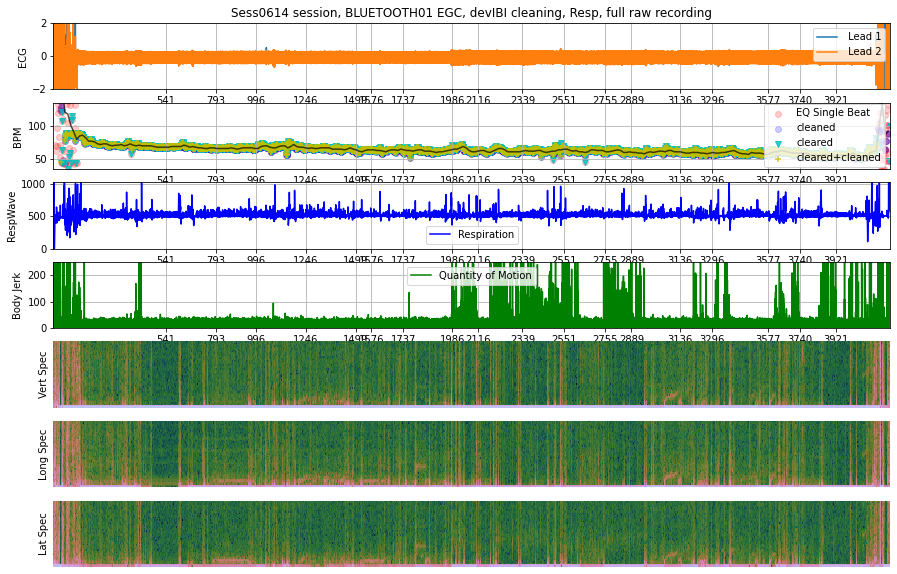

In [19]:
fig, (ax) = plt.subplots(7, 1,figsize = [15,10])
ax[0].plot(C['c_sTime'],C[[' Lead 1',' Lead 2']],label=[' Lead 1',' Lead 2'])
ax[0].set_title(sess_tag + ' session, '+ dev_tag +' EGC, devIBI cleaning, Resp, full raw recording' )
ax[0].set(ylabel = 'ECG',xticks = Exticks,xlim = xrange,ylim = [-2,2])
ax[0].grid()
ax[0].legend()

ax[1].scatter(x =sig_t,y=(60000/sig_v),color='r',alpha = 0.2,label='EQ Single Beat')
ax[1].scatter(x = IBI.index,y = (60000/IBI['IBI']),color='b',alpha = 0.2,label='cleaned')
ax[1].scatter(x =newV['c_sTime'],y=(60000/newV[' Interbeat Interval (MS)']),color='c',marker = 'v',alpha = 0.8,label='cleared')
ax[1].scatter(x = newIBI.index,y = (60000/newIBI['IBI']),color='y',marker = '+',alpha = 0.8,label='cleared+cleaned')
ax[1].grid()
ax[1].legend()
ax[1].plot(D['c_sTime'],D['HR(BPM)'],alpha=0.7,c='k',label='EQHR')
ax[1].set(ylabel='BPM',ylim=[35,135],xticks = Exticks, xlim = xrange)

ax[2].plot(R['c_sTime'],R[' Breathing'],color = 'b',label='Respiration')
ax[2].set(xlabel = 'Time (s), Session',ylabel = 'RespWave',xticks = Exticks,xlim = xrange,ylim = [0,1024])
ax[2].grid()
ax[2].legend()

ax[3].plot(A['c_sTime'],A['QoM'],color = 'g',label='Quantity of Motion')
ax[3].set(xticks = Exticks,ylabel = 'Body Jerk',ylim = [0,250], xlim = xrange)
ax[3].grid()
ax[3].legend()
chart = sns.heatmap(data=spec[' Vert Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix", cbar = False, ax=ax[4])
ax[4].set(xticks = [],yticks=[],ylabel='Vert Spec')
chart = sns.heatmap(data=spec[' Long Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix", cbar = False, ax=ax[5])
ax[5].set(xticks = [],yticks=[],ylabel='Long Spec')
chart = sns.heatmap(data=spec[' Lat Accelerometer'].loc[:,Hz[::-1]].transpose(),vmin=0, vmax=80,cmap="cubehelix",cbar = False,  ax=ax[6])
ax[6].set(xticks = [],yticks=[],ylabel='Lat Spec')
plt.savefig('_'.join(['./plots/'+sess_tag + '/'+sess_tag,'FullRec',dev_tag+'.jpg']))
plt.show()

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:32:48', 'Recording': 5, 'Initial Beat Count': 69, 'Cleaned Beat Count': 69, 'PC Removed': 0.0, 'Avg HR': 68.68861162728962, 'RMSSD': 9.951352258095675, 'Avg eqHR': 68.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 20, 'Avg BR': 19.971495139159, 'Avg IE ratio': 0.6347768689506963, 'Seq Var': 1.1714704913329304, 'Avg QoM': 11.227642402887314}


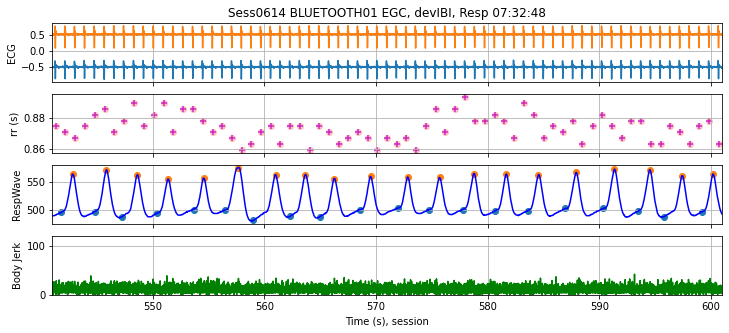

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:37:00', 'Recording': 5, 'Initial Beat Count': 66, 'Cleaned Beat Count': 66, 'PC Removed': 0.0, 'Avg HR': 66.3005625502277, 'RMSSD': 13.728689780052687, 'Avg eqHR': 66.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 13, 'Avg BR': 14.42200222287575, 'Avg IE ratio': 0.22598673829108584, 'Seq Var': 1.3214787481503896, 'Avg QoM': 12.339826112082566}


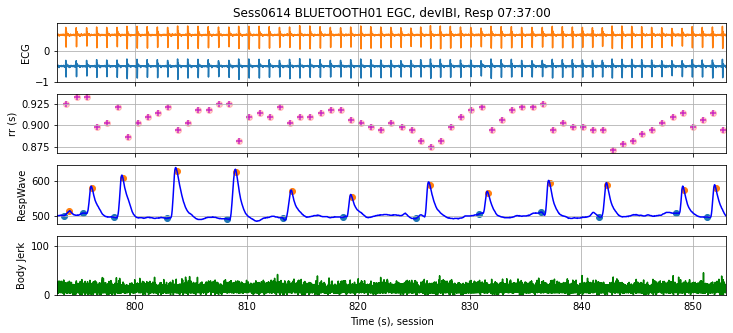

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:40:23', 'Recording': 5, 'Initial Beat Count': 69, 'Cleaned Beat Count': 69, 'PC Removed': 0.0, 'Avg HR': 69.24929747089523, 'RMSSD': 12.100072921510943, 'Avg eqHR': 68.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 20.556804147964083, 'Avg IE ratio': 0.4301363499649896, 'Seq Var': 1.5060831878137981, 'Avg QoM': 12.591409962389502}


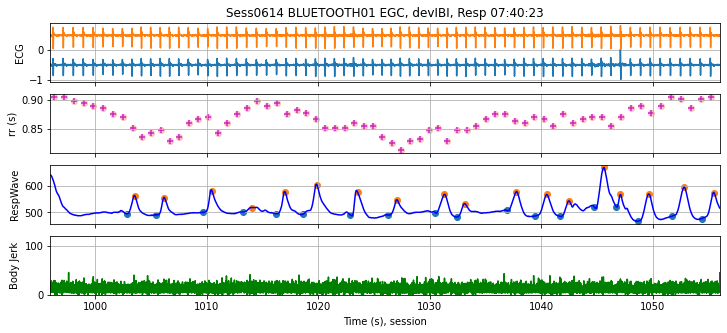

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:44:33', 'Recording': 5, 'Initial Beat Count': 66, 'Cleaned Beat Count': 66, 'PC Removed': 0.0, 'Avg HR': 66.49315758542524, 'RMSSD': 15.11443528042493, 'Avg eqHR': 66.25, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 13, 'Avg BR': 16.094788067851272, 'Avg IE ratio': 0.2706219913670308, 'Seq Var': 1.610725007202317, 'Avg QoM': 11.895185503815073}


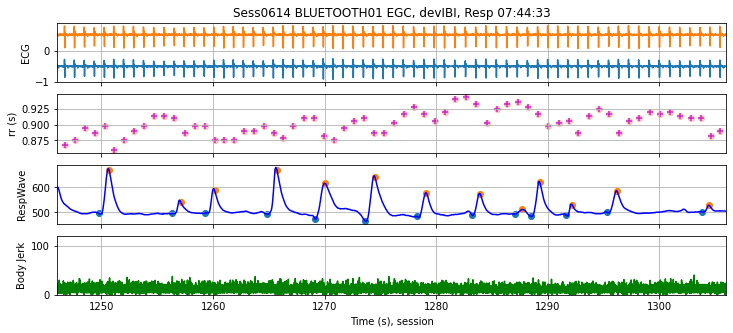

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:48:46', 'Recording': 5, 'Initial Beat Count': 63, 'Cleaned Beat Count': 63, 'PC Removed': 0.0, 'Avg HR': 62.4783061437001, 'RMSSD': 20.431632653883188, 'Avg eqHR': 62.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 20.90199884503073, 'Avg IE ratio': 0.42107231830352426, 'Seq Var': 1.6371889440716105, 'Avg QoM': 11.97356033011732}


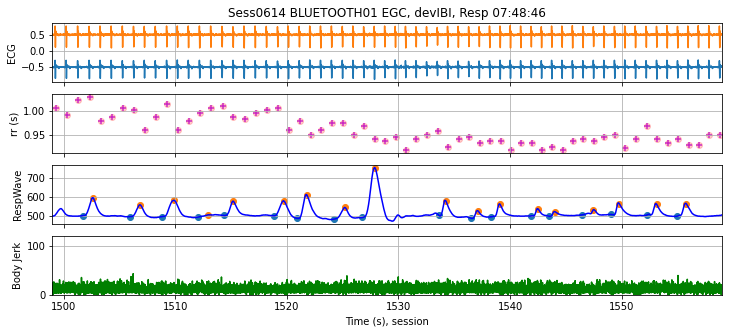

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:50:03', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 62.69275494211032, 'RMSSD': 18.93258099020891, 'Avg eqHR': 63.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 23.101846794322434, 'Avg IE ratio': 0.37518625814838924, 'Seq Var': 1.7209530648261424, 'Avg QoM': 11.907434669081587}


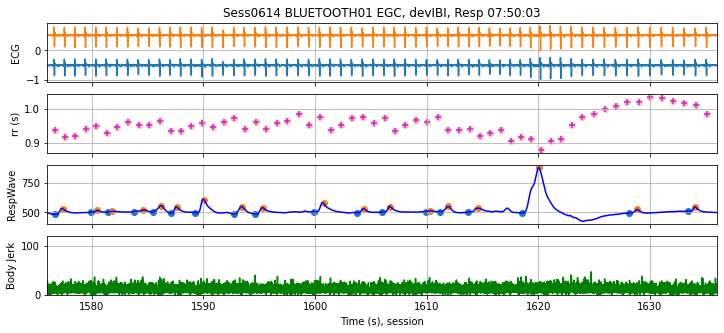

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:52:44', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 62.70649315622682, 'RMSSD': 29.38857813148101, 'Avg eqHR': 63.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 20.448373060651413, 'Avg IE ratio': 0.5360781249741331, 'Seq Var': 1.4097659267071718, 'Avg QoM': 12.27212469707473}


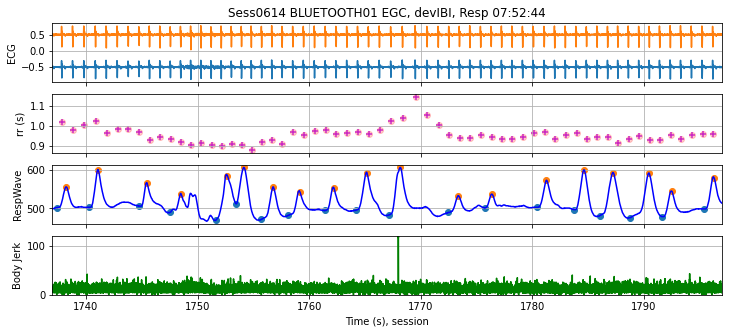

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:56:53', 'Recording': 5, 'Initial Beat Count': 67, 'Cleaned Beat Count': 67, 'PC Removed': 0.0, 'Avg HR': 67.06035431888701, 'RMSSD': 15.599630920264904, 'Avg eqHR': 66.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 23.6592347201769, 'Avg IE ratio': 0.526329738690331, 'Seq Var': 1.639579757725645, 'Avg QoM': 14.11604814774489}


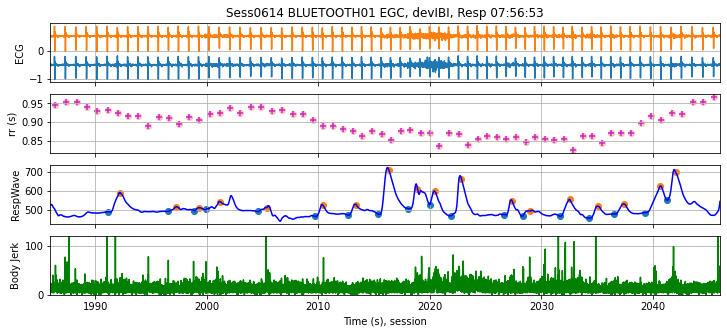

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 07:59:03', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 61.86184188645359, 'RMSSD': 20.3377223606694, 'Avg eqHR': 61.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 21.763479853577408, 'Avg IE ratio': 0.5131488225968873, 'Seq Var': 1.3710787002351552, 'Avg QoM': 12.245598857623731}


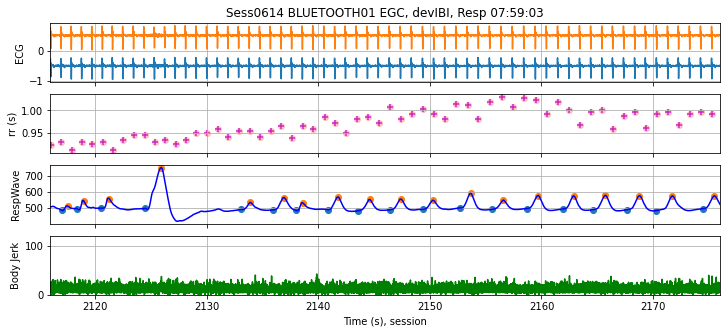

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:02:46', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 62.25003765123245, 'RMSSD': 24.413446979945764, 'Avg eqHR': 62.25, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 20, 'Avg BR': 25.427372988863574, 'Avg IE ratio': 0.5236995876448988, 'Seq Var': 1.6798953744980076, 'Avg QoM': 13.381683676175099}


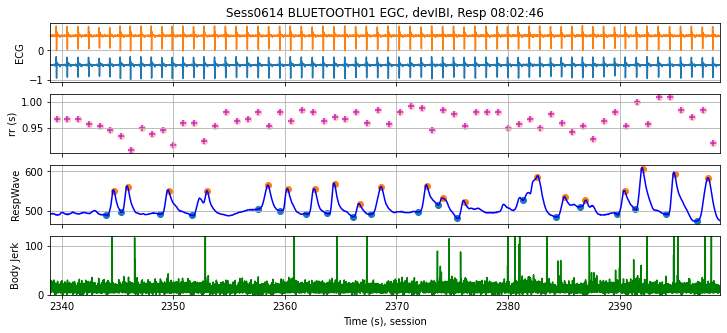

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:06:18', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 62.65896343209419, 'RMSSD': 23.05837211492095, 'Avg eqHR': 63.25, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 19, 'Avg BR': 21.87385200084831, 'Avg IE ratio': 0.4718625009481138, 'Seq Var': 1.4536652531410015, 'Avg QoM': 12.986486843358913}


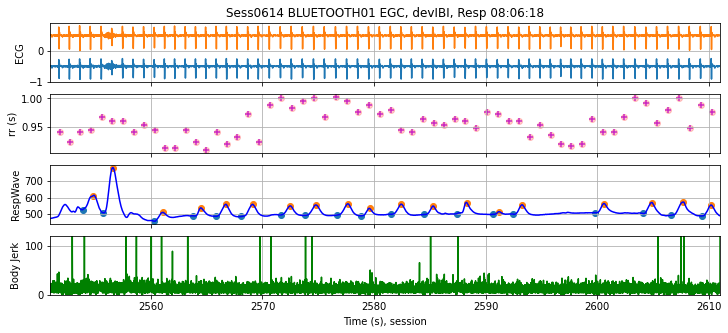

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:09:42', 'Recording': 5, 'Initial Beat Count': 63, 'Cleaned Beat Count': 63, 'PC Removed': 0.0, 'Avg HR': 62.37006237006237, 'RMSSD': 26.414805232745348, 'Avg eqHR': 61.75, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 22.865713530748707, 'Avg IE ratio': 0.44218186524679, 'Seq Var': 1.8790321381100086, 'Avg QoM': 13.594715001521951}


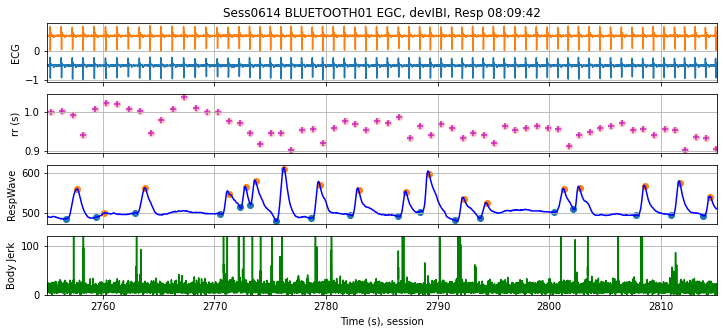

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:11:56', 'Recording': 5, 'Initial Beat Count': 59, 'Cleaned Beat Count': 59, 'PC Removed': 0.0, 'Avg HR': 59.05610329813322, 'RMSSD': 24.96825570806756, 'Avg eqHR': 59.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 15, 'Avg BR': 18.067899165126075, 'Avg IE ratio': 0.3727563092156168, 'Seq Var': 1.552522915789162, 'Avg QoM': 12.676916911994784}


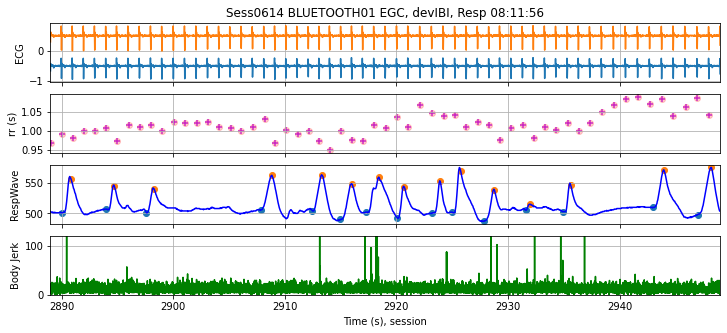

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:16:03', 'Recording': 5, 'Initial Beat Count': 59, 'Cleaned Beat Count': 59, 'PC Removed': 0.0, 'Avg HR': 59.4698115109364, 'RMSSD': 33.257874359263425, 'Avg eqHR': 59.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Prone', 'Breath Count': 17, 'Avg BR': 19.872268494032323, 'Avg IE ratio': 0.34791484491477304, 'Seq Var': 1.3700346716890932, 'Avg QoM': 12.390138488559927}


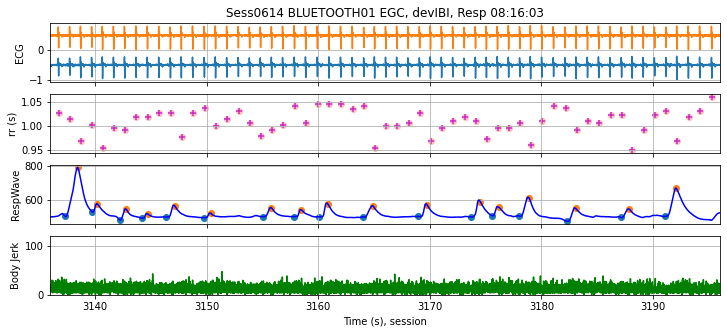

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:18:43', 'Recording': 5, 'Initial Beat Count': 59, 'Cleaned Beat Count': 59, 'PC Removed': 0.0, 'Avg HR': 59.13897659499825, 'RMSSD': 27.952545994706938, 'Avg eqHR': 59.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 11, 'Avg BR': 16.271978446564102, 'Avg IE ratio': 0.6921688922635535, 'Seq Var': 1.9164918591797193, 'Avg QoM': 12.684924548648977}


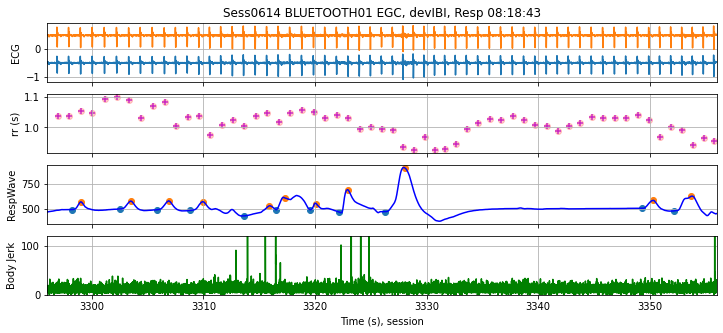

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:23:24', 'Recording': 5, 'Initial Beat Count': 62, 'Cleaned Beat Count': 62, 'PC Removed': 0.0, 'Avg HR': 61.16509643368026, 'RMSSD': 27.831165453351094, 'Avg eqHR': 60.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 15, 'Avg BR': 19.238806015064338, 'Avg IE ratio': 0.38981112836919735, 'Seq Var': 2.0455698691741935, 'Avg QoM': 12.835939771993845}


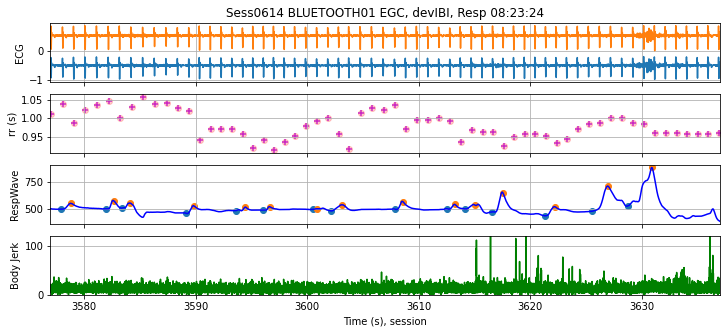

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:26:07', 'Recording': 5, 'Initial Beat Count': 57, 'Cleaned Beat Count': 57, 'PC Removed': 0.0, 'Avg HR': 57.53604414461398, 'RMSSD': 26.079548637636677, 'Avg eqHR': 58.0, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 18.97949044285607, 'Avg IE ratio': 0.5471452151168649, 'Seq Var': 1.2848089174802952, 'Avg QoM': 12.467150928183544}


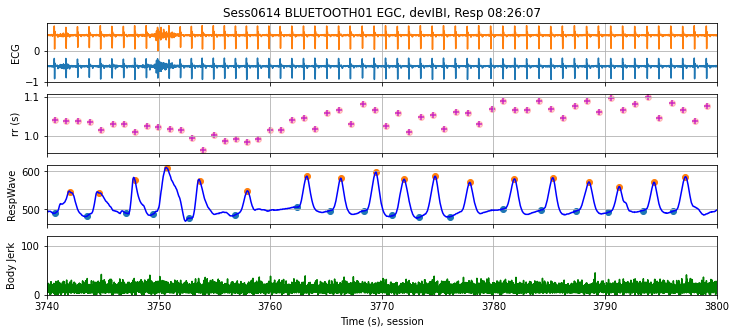

{'Device': 'BLUETOOTH01', 'Start Time': '2023/06/14 08:29:08', 'Recording': 5, 'Initial Beat Count': 56, 'Cleaned Beat Count': 56, 'PC Removed': 0.0, 'Avg HR': 55.75467941059339, 'RMSSD': 31.034877740433203, 'Avg eqHR': 55.5, 'Mode Motion': 'Stationary', 'Mode Posture': 'Upright', 'Breath Count': 18, 'Avg BR': 19.046518117784025, 'Avg IE ratio': 0.5098767685576934, 'Seq Var': 1.0540765147704698, 'Avg QoM': 12.419934489908774}


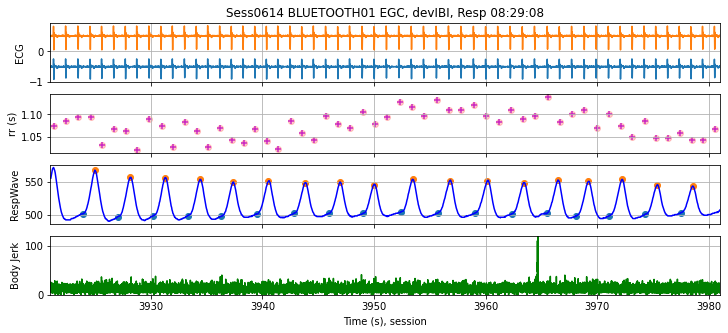

In [20]:
t_int =60
sig_ex = sess_tag + ' '+ dev_tag
session_stats = {}
for t in Excerpt_times: #17
    # needs to be corrected when the files have the right correspondence    
    cht = (t-eqfiles.loc[recindex,'RecStart']).total_seconds()
    chx = cht+t_int
    
    interval_stats = {}
    interval_stats['Device'] = dev_tag
    interval_stats['Start Time'] = t.strftime('%Y/%m/%d %H:%M:%S')
    interval_stats['Recording'] = recindex
    
    fig, (ax) = plt.subplots(4, 1,figsize = [12,5],sharex = True)
    Ex = C.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 1']-0.5)
    ax[0].plot(Ex['c_sTime'],Ex[' Lead 2']+0.5)
    ax[0].set_ylabel('ECG')
    ax[0].set_title(sig_ex +' EGC, devIBI, Resp ' + t.strftime('%H:%M:%S') )
    ax[0].set_xlim([cht,chx])
#     ax[0].set_ylim([-1.5,1.5])
    Ex = V.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Initial Beat Count'] = len(Ex)

    ax[1].scatter(x =Ex['c_sTime'],y=(Ex[' Interbeat Interval (MS)']/1000),color='r',alpha = 0.2,label='Single Beat')
    Ex = newIBI.query('time>@cht and time<@chx').copy()
    interval_stats['Cleaned Beat Count'] =Ex['IBI'].notna().sum()
    interval_stats['PC Removed'] = 100*np.round((interval_stats['Initial Beat Count'] - interval_stats['Cleaned Beat Count'])/interval_stats['Initial Beat Count'],3)
    ax[1].scatter(x = Ex.index,y = Ex['IBI']/1000,color='m',marker = '+',alpha = 0.8,label='cleared+cleaned')
    interval_stats['Avg HR'] = HR_avg(Ex['IBI'])
    interval_stats['RMSSD'] =rmssd(Ex['IBI'])
    Ex = D.query('c_sTime>@cht and c_sTime<@chx').copy()
    interval_stats['Avg eqHR'] = Ex['HR(BPM)'].mean()
    interval_stats['Mode Motion'] = Ex['MOTION'].mode()[0]
    interval_stats['Mode Posture'] = Ex['BODY POSITION'].mode()[0]
#     ax[1].plot(D['c_sTime'],60/D['HR(BPM)'],alpha=0.7,c='k',label='EQHR')
#     ax[1].legend()
    ax[1].set_ylabel('rr (s)')
#     ax[1].set_ylim([400,1400])

    Ex = R.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[2].plot(Ex['c_sTime'],Ex[' Breathing'],color = 'b',label='Respiration')
    Ex = Breaths.query('In>@cht and Ex<@chx').copy()
    ax[2].scatter(Ex['In'],Ex['In_C'])
    ax[2].scatter(Ex['Ex'],Ex['Ex_C'])
    ax[2].set_ylabel('RespWave')
    interval_stats['Breath Count'] = len(Ex)
    interval_stats['Avg BR'] =(60/Ex['Period_T']).mean()
    interval_stats['Avg IE ratio'] =(Ex['IE_Ratio']).mean()
    interval_stats['Seq Var'] =np.power(10,np.log10((Ex['Period_T']/Ex['Period_T'].shift(-1))).abs().mean())


    Ex = A.query('c_sTime>@cht and c_sTime<@chx').copy()
    ax[3].plot(Ex['c_sTime'],Ex['QoM'],color = 'g',label='Quantity of Motion')
    ax[3].set(xlabel = 'Time (s), session',ylabel = 'Body Jerk',ylim = [0,120])
    interval_stats['Avg QoM'] =Ex['QoM'].mean()

    ax[3].grid()
    ax[2].grid()
    ax[1].grid()
    ax[0].grid()
    print(interval_stats)
    session_stats[t.strftime('%Y/%m/%d %H:%M:%S')] = interval_stats
    plt.savefig('_'.join(['./plots/'+sess_tag + '/'+sess_tag,t.strftime('%H%M%S'),dev_tag,'excerpt.jpg']))
    plt.show()

Evaluated_Intervals =pd.DataFrame(data=session_stats).transpose()
Evaluated_Intervals.to_csv('_'.join(['./outfiles/'+sess_tag,dev_tag,'fullstats.csv']))

In [21]:

Evs.append(Evaluated_Intervals.copy())

In [22]:
Ex_stats = pd.concat(Evs)

Dan recommended to check manually a very small sample (5 or 10 intervals) at the start of the process. He also wondered if there was a way to track how many artefacts are detected (to be able to report in the article that f.ex "on average, 2% of beats were detected as artefacts"). With regards to respiration, he thought that respiration rate would be best to use as a control - Finn, this is your area of expertise, so we defer to you there.

In [23]:
sub_stats = Ex_stats[['Device','Avg HR','RMSSD','PC Removed','Breath Count','Avg IE ratio','Seq Var','Avg QoM']]
sub_stats.to_csv('./outfiles/'+sess_tag+'_summary.csv')
sub_stats

,Device,Avg HR,RMSSD,PC Removed,Breath Count,Avg IE ratio,Seq Var,Avg QoM
2023/06/14 07:32:48,BLUETOOTH02,78.757165,17.558328,0.0,18,0.3624,1.098969,11.125173
2023/06/14 07:37:00,BLUETOOTH02,87.887211,16.373865,0.0,13,0.364029,1.523518,11.89115
2023/06/14 07:40:23,BLUETOOTH02,82.707766,16.299783,0.0,16,0.332596,1.856771,10.670022
2023/06/14 07:44:33,BLUETOOTH02,86.826347,20.800268,0.0,13,0.312265,1.383628,11.989878
2023/06/14 07:48:46,BLUETOOTH02,80.920428,15.45639,0.0,12,0.478584,1.707102,11.155459
2023/06/14 07:50:03,BLUETOOTH02,75.54138,22.425854,0.0,16,0.424241,1.573612,10.810621
2023/06/14 07:52:44,BLUETOOTH02,80.4769,17.935649,0.0,15,0.44261,2.11538,11.298059
2023/06/14 07:56:53,BLUETOOTH02,77.196852,18.844586,0.0,19,0.41143,1.413131,11.185046
2023/06/14 07:59:03,BLUETOOTH02,73.921555,24.616785,0.0,17,0.40208,1.80636,10.65146
2023/06/14 08:02:46,BLUETOOTH02,74.965016,23.241389,0.0,15,0.46603,1.61279,11.338841


Sess0607_summary.csv 

'Device': the sensor name
'Avg HR': Average heart rate for the 60s excerpt, the inverse average RR * 60 
'RMSSD': the usual
'PC Removed': the percentage of beats removed according to my cleaning process that cuts beats based on electrode noise in the ECG signal and extreme outlier beats (ectopic probably). calculations in the mh.py function file.
'Breath Count': The number of breaths detected during the 60 s interval, so roughly BPM
'Avg IE ratio': Inspiration time to Expiration time ratio, common for speach detections
'Seq Var': Average (logarithmic) sequential difference in sequential breath duration
'Avg QoM': Average intantaneous jerk magnitude, related to how much body motion occured

So if you open the csv file in excel you can copy past the values you want in to the excel spreadsheets. 

The signals for each interval have also been ploted, so you can take a look at to see if there are issues with the signals that change your interpretation of these summary statistics. 